In [1]:
from augmentation import augmentor
import pandas as pd

In [2]:
dataset = augmentor("./data_rearranged.csv")

In [3]:
reduced_derived = dataset.toReduced(returnDF=True,save=False)
reduced = pd.read_csv("../reduced_dataset/reduced_data.csv")
reduced.sort_values(by=['Row','y'],inplace=True)
reduced.reset_index(drop=True,inplace=True)
print(f"Is close match to original reduced data? {pd.testing.assert_frame_equal(reduced, reduced_derived, check_exact=False, rtol=1e-10, atol=1e-3) is None}")

Is close match to original reduced data? True


In [4]:
# Good noise parameters: 
#    weights = [0.2,0.2,0.6], intensities=[5e-9, 2e-8, 8e-8]
#    weights = [0.8,0.1,0.1], intensities=[1e-9, 7e-8, 3e-7]
dataset.createNoisyData(150,[0.2,0.2,0.6],intensities=[3e-9,4e-8,1e-7])

Average dB SNR: 13.646044169540827 dB
Noise Intensities:
	Shot: 3e-09
	Pink: 4e-08
	Brownian: 1e-07


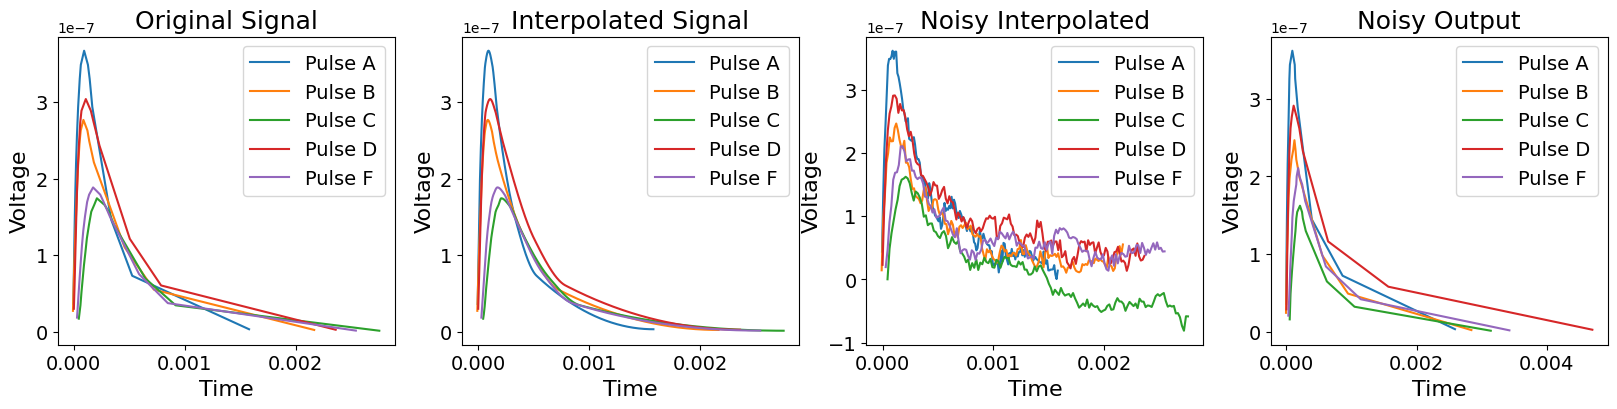

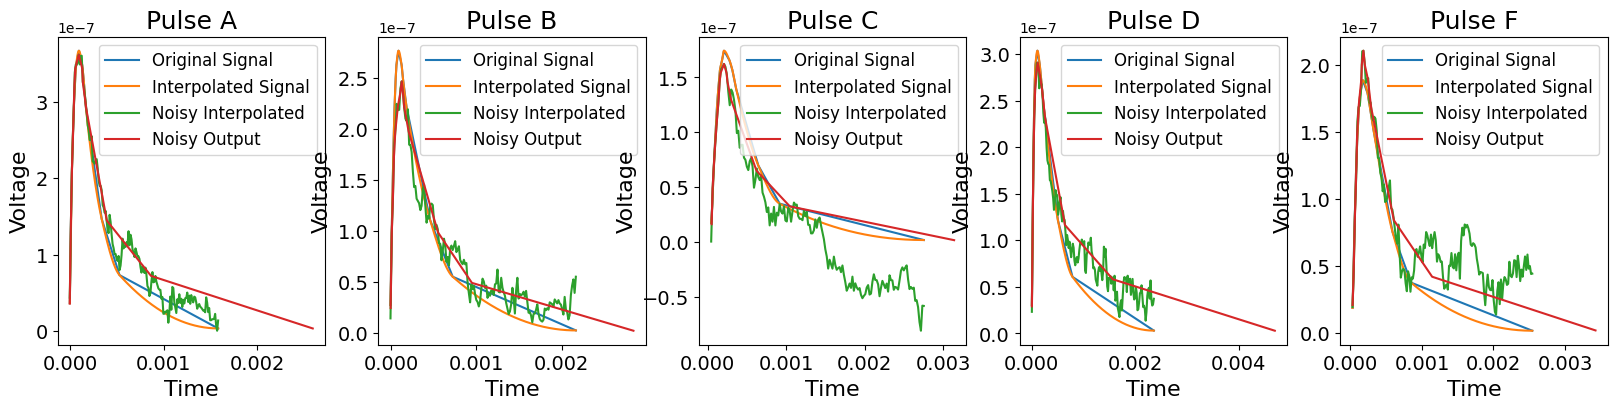

In [5]:
dataset.plotSignals(1630)

In [15]:
# Optional : save full noisy dataset (for Trasnformer or CNN use)
dataset.saveNoisyData()

In [69]:
# Save reduced noise dataset (for DNN)
dataset.toReduced(noisy=True)